<a target="_blank" href="https://colab.research.google.com/github/argologabriel/galaxy10-ml-classification/blob/main/Galaxy10_DenseNet.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Projeto Final: Classificação Automática de Galáxias com DenseNet121**

**Disciplina:** Fundamentos da Inteligência Artificial  
**Integrantes:**
1. Davi Oliveira Machado
2. Gabriel Argôlo Julião dos Santos
3. João Pedro Oliveira Freitas

**Dataset:** Galaxy10 DECals  
**Modelo:** DenseNet121 (Transfer Learning / Fine-Tuning)  

---
### **Estrutura do Documento**
1. **Definição do Problema, Compreensão e Descrição dos Dados**
2. **Análise Exploratória e Interpretação de Figuras/Tabelas**
3. **Pré-processamento e Justificativas Técnicas**
4. **Separação dos Dados e Desenho Experimental**
5. **Arquitetura do Modelo, Hiperparâmetros e Treinamento**
6. **Avaliação das Métricas, Discussão Crítica de Resultados, Erros e Limitações**


## **1. Definição do Problema e Compreensão dos Dados**

### **1.1 Contexto e Definição da Tarefa**
- **Objetivo:** Classificação multiclasse de imagens astronômicas de galáxias obtidas pelo levantamento *Dark Energy Camera Legacy Survey (DECals)*.
- **Tipo de Tarefa:** Aprendizado Supervisionado, Classificação de Imagens.
- **Relevância:** A classificação morfológica de galáxias é fundamental na astrofísica para compreender a evolução estelar, fusões galácticas e a distribuição de matéria no universo. A classificação manual por astrônomos ou ciência cidadã é inviável para grandes volumes de dados, tornando indispensável o uso de Redes Neurais Convolucionais.

### **1.2 Descrição do Dataset Galaxy10 DECals**
- **Total de Amostras:** 17.736 imagens coloridas.
- **Dimensão Original:** Imagens de 69 X 69 pixels em formato HDF5 (`Galaxy10.h5`).
- **Número de Classes:** 10 classes morfológicas bem definidas:
  0. *Disturbed Galaxies* (Galáxias distorcidas)
  1. *Merging Galaxies* (Galáxias em processo de fusão)
  2. *Round Smooth Galaxies* (Galáxias elípticas)
  3. *In-between Round Smooth Galaxies* (Galáxias elípticas ovais)
  4. *Cigar Shaped Smooth Galaxies* (Galáxias elípticas em formato de charuto)
  5. *Barred Spiral Galaxies* (Galáxias espirais com barra central)
  6. *Unbarred Tightly Wound Spiral Galaxies* (Espirais sem barra com braços firmes)
  7. *Unbarred Loose Spiral Galaxies* (Espirais sem barra com braços abertos)
  8. *Edge-on Galaxies without Bulge* (Galáxias de perfil sem bojo)
  9. *Edge-on Galaxies with Bulge* (Galáxias de perfil com bojo central)


# Bibliotecas

Bibliotecas Python utilizadas no trabalho

In [ ]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import gc
import albumentations as A

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


import random
import numpy as np
import albumentations as A
import gc

# Download do dataset

Rode a célula abaixo para baixar o dataset (~2.5 GB).

In [ ]:
# Rode essa célula se o dataset estiver no google drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import requests

def download_dataset():
  DATASET_PATH1 = "/content/drive/MyDrive/Galaxy10_DECals.h5"
  DATASET_PATH2 = "Galaxy10_DECals.h5"


  file_path1 = Path(DATASET_PATH1)
  file_path2 = Path(DATASET_PATH2)

  if file_path1.exists():
    print(f"Dataset encontrado em {file_path1}")
    return DATASET_PATH1
  elif file_path2.exists():
    print(f"Dataset encontrado em {file_path2}")
    return DATASET_PATH2
  else:
    print("Dataset não encontrado. Baixando...")
    url = "https://zenodo.org/records/10845026/files/Galaxy10_DECals.h5"
    response = requests.get(url)
    response.raise_for_status()
    with open(DATASET_PATH2, "wb") as file:
      file.write(response.content)
    print("Dataset baixado")
    return DATASET_PATH2
DATASET_PATH = download_dataset()
print(DATASET_PATH)

Dataset encontrado em /content/drive/MyDrive/Galaxy10_DECals.h5
/content/drive/MyDrive/Galaxy10_DECals.h5


## **2. Análise Exploratória, Pré-processamento e Data Augmentation**

### **2.1 Análise Crítica dos Dados e Desbalanceamento**
- O conjunto original do Galaxy10 DECals apresenta **desbalanceamento severo de classes**. As classes mais comuns, como *Round Smooth* e *In-between Smooth* possuem milhares de exemplos, enquanto classes raras e complexas, como *Disturbed Galaxies* e *Barred Spiral* possuem substancialmente menos.
- **Impacto no Modelo:** Modelos treinados em conjuntos desbalanceados tendem a priorizar as classes com mais exemplos, resultando em uma falsa alta acurácia global, mas baixo *recall* e *F1-score* nas classes menores.

### **2.2 Estratégia de Aumento de Dados (Data Augmentation)**
- Para diminuir o desbalanceamento do modelo, aplicou-se a técnica de **Aumento de Dados Sintético**.
- **Propriedade Física do Problema:** Na astronomia, a orientação de uma galáxia no céu é arbitrária em relação à Terra. Rotações e espelhamentos preservam integralmente a morfologia física da galáxia.
- **Operações Utilizadas:**
  - Rotações aleatórias em 90°, 180° e 270° (`RandomRotate90`).
  - Inversão Horizontal e Vertical (`HorizontalFlip`, `VerticalFlip`).
- **Garantia Anti-Vazamento (Data Leakage):** O aumento sintético de dados foi aplicado exclusivamente no conjunto de **treino**, mantendo o conjunto de validação original.

# Aumento de dados (Data augmentation)

A orientação de galáxias não importa. Podemos rotacionar, inverter e redimensionar galáxias para aumentar o número de imagens no dataset. Dessa forma, conseguimos balancear as classes.

Apenas o conjunto de treino é aumentado.

In [ ]:
def augment_dataset(images, labels, seed=42):
    # 1. Seed Python's native random module (used by Albumentations)
    random.seed(seed)

    rng = np.random.default_rng(seed)

    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5)
    ])

    unique_classes, counts = np.unique(labels, return_counts=True)
    target_count = np.max(counts)

    augmented_images_list = []
    augmented_labels_list = []

    for class_idx, current_count in zip(unique_classes, counts):
        needed = target_count - current_count
        if needed <= 0:
            continue
        print(f"Class {class_idx}: Generating {needed} balanced samples.")

        class_indices = np.where(labels == class_idx)[0]

        for _ in range(needed):
            # Use the local random generator instead of global np.random.choice
            rand_idx = rng.choice(class_indices)
            orig_img = images[rand_idx]

            augmented = transform(image=orig_img)
            augmented_images_list.append(augmented['image'])
            augmented_labels_list.append(class_idx)

    if augmented_images_list:
        augmented_images_arr = np.array(augmented_images_list, dtype=images.dtype)
        del augmented_images_list

        balanced_images = np.concatenate([images, augmented_images_arr], axis=0)
        del augmented_images_arr

        balanced_labels = np.concatenate([labels, np.array(augmented_labels_list, dtype=labels.dtype)], axis=0)

        gc.collect()
        return balanced_images, balanced_labels

    return images, labels

# Wrapper do dataset

Classe que armazena o dataset para uso com pytorch

In [ ]:
class Galaxy10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.images[index]
        label = torch.tensor(self.labels[index], dtype=torch.long)

        if self.transform:
            image = self.transform(image)
        return image, label

## **3. Transformações, Desenho Experimental e Separação dos Dados**

### **3.1 Pré-processamento e Transformações PyTorch**
1. **Redimensionamento (244 X 244):** As imagens originais são redimensionadas para 224 X 224 pixels para compatibilidade com a entrada padrão da arquitetura DenseNet121.
2. **Conversão para Tensor e Normalização:** Aplica-se a normalização dos canais de cor com a média e desvio padrão ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`), garantindo convergência estável do gradiente.

### **3.2 Desenho Experimental e Divisão do Dataset**
- **Divisão Hold-Out (80% / 20%):**
  - **Conjunto de Treino (80%):** Utilizado para o ajuste dos pesos da rede neural com *Data Augmentation*.
  - **Conjunto de Validação (20%):** Mantido intacto para avaliação não-viesada da capacidade de generalização do modelo.
- **Reprodutibilidade:** Fixou-se a semente aleatória (`seed = 42`) no PyTorch e NumPy.

# Transformações

Transformações realizadas durante o treinamento e validação para aumentar a variação dos dados.

In [ ]:
train_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224,224)),
  transforms.RandomRotation(180),
  transforms.RandomHorizontalFlip(),
  transforms.RandomVerticalFlip(),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.1694602, 0.16505311, 0.16109793], std=[0.1180005, 0.10668223, 0.10167886])
])

validation_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224,224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.1694602, 0.16505311, 0.16109793], std=[0.1180005, 0.10668223, 0.10167886])
])

# Carregamento do dataset



In [ ]:

print("Loading dataset...")
with h5py.File(DATASET_PATH, 'r') as f:
    dataset_images = f['images'][:]
    dataset_labels = f['ans'][:]
print("Dataset loaded into ram.")

total_samples = len(dataset_images)
indices = np.arange(total_samples)
np.random.shuffle(indices)

train_size = int(0.8 * total_samples)
train_idx, val_idx = indices[:train_size], indices[train_size:]

val_images = dataset_images[val_idx]
val_labels = dataset_labels[val_idx]

train_images = dataset_images[train_idx]
train_labels = dataset_labels[train_idx]

del dataset_images, dataset_labels
gc.collect()

train_images, train_labels = augment_dataset(train_images, train_labels)

Loading dataset...
Dataset loaded into ram.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Class 0: Generating 1262 balanced samples.
Class 1: Generating 644 balanced samples.
Class 3: Generating 525 balanced samples.
Class 4: Generating 1862 balanced samples.
Class 5: Generating 504 balanced samples.
Class 6: Generating 668 balanced samples.
Class 7: Generating 56 balanced samples.
Class 8: Generating 1016 balanced samples.
Class 9: Generating 615 balanced samples.


## **4. Arquitetura do Modelo, Hiperparâmetros e Treinamento**

### **4.1 Escolha da Arquitetura: DenseNet121**
- **Por que DenseNet121?** Diferente de redes como ResNet que somam *feature maps*, a DenseNet concatena mapas de características de todas as camadas anteriores no mesmo bloco denso (*Dense Block*).
- **Vantagens Práticas:**
  - **Reutilização de Features:** Captura tanto detalhes finos de baixa complexidade (bordas e gradientes de brilho das galáxias) quanto estruturas complexas de alta abstração (braços espirais e núcleos).
  - **Redução do Gradient Vanishing:** Conexões diretas garantem fluxo contínuo do gradiente durante o *backpropagation*.
  - **Eficiência de Parâmetros:** Possui menos parâmetros (~7 milhões) que a ResNet50 (~25 milhões), reduzindo o risco de *overfitting* em datasets astronômicos médios.

### **4.2 Hiperparâmetros e Estratégia de Treinamento**
- **Otimizador:** `AdamW` (Taxa de aprendizado inicial $1 \times 10^{-4}$ com penalização de peso $1 \times 10^{-4}$ para regularização L2).
- **Função de Perda:** `CrossEntropyLoss` com *Label Smoothing* ($0.1$), evita que a rede fique superconfiante em rótulos ruidosos ou ambíguos.
- **Agendador de LR:** `ReduceLROnPlateau` (fator $0.5$, paciência 3 épocas no *validation loss*).
- **Parada Antecipada (Early Stopping):** Monitora a perda na validação com paciência de 15 épocas para impedir *overfitting*.

# Configuração do modelo

O modelo utilizado é o DenseNet. Nesse modelo, todas as camadas recebem informações das camadas anteriores.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.densenet121(weights=None)

num_classes = 10
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
model = model.to(device)

print(f"Treinando no dispositivo: {device}")

# Redefine the transforms to include ToPILImage() for proper handling of numpy arrays
train_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224,224)),
  transforms.RandomRotation(180),
  transforms.RandomHorizontalFlip(),
  transforms.RandomVerticalFlip(),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.1694602, 0.16505311, 0.16109793], std=[0.1180005, 0.10668223, 0.10167886])
])

validation_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224,224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.1694602, 0.16505311, 0.16109793], std=[0.1180005, 0.10668223, 0.10167886])
])

train_dataset = Galaxy10Dataset(train_images, train_labels, transform=train_transform)
val_dataset = Galaxy10Dataset(val_images, val_labels, transform=validation_transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Label smoothing melhora a classificação de galáxias difíceis de classificar, como a classe 0
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

scaler = torch.amp.GradScaler(device.type, enabled=(device.type=='cuda'))

Treinando no dispositivo: cuda


# Loop de treinamento
##**Para baixar o modelo pré-treinado, pule essa célula.**

Rode a célula abaixo para treinar o modelo do zero. O treinamento dura cerca de 2h.

In [ ]:
OUT_PATH = "GalaxyModel_DenseNet.pth"

num_epochs = 200
PATIENCE = 15
patience_counter = 0
min_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_total = 0
    train_correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
          for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = (train_correct / train_total) * 100

    epoch_val_loss = val_loss / total
    epoch_val_acc = (correct / total) * 100


    scheduler.step(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")

    if epoch_val_loss < min_val_loss:
        patience_counter = 0
        min_val_loss = epoch_val_loss
        print(f"Melhoria do Loss! Salvando checkpoint...")
        torch.save(model.state_dict(), OUT_PATH)
    else:
        patience_counter += 1
        print(f"Sem melhorias. Paciência: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Paciência limite ultrapassada!")
        break

print("Treino finalizado...")

# Download de modelo pré-treinado

Rode a célula abaixo para baixar o modelo já treinado no dataset Galaxy10 DECalS

In [ ]:
from huggingface_hub import hf_hub_download

model_file_path = hf_hub_download(
    repo_id = "JPedro108/Galaxy10_DenseNet121",
    filename="GalaxyModel_DenseNet_Label_Smoothing.pth",
    local_dir="."
    #filename="GalaxyModel_DenseNet.pth"
)
print(model_file_path)

GalaxyModel_DenseNet_Label_Smoothing.pth: reconstructing file:   0%|          |  0.00B / 29.5MB            

GalaxyModel_DenseNet_Label_Smoothing.pth: downloading bytes:           |  0.00B            

/content/GalaxyModel_DenseNet_Label_Smoothing.pth


# Inferência no set de validação

O modelo é usado para classificar as galáxias no set de validação.

In [ ]:
checkpoint_path = model_file_path
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

GALAXY10_CLASSES = {
    0: "Disturbed Galaxies",
    1: "Merging Galaxies",
    2: "Round Smooth Galaxies",
    3: "In-between Round Smooth Galaxies",
    4: "Cigar Shaped Smooth Galaxies",
    5: "Barred Spiral Galaxies",
    6: "Unbarred Tight Spiral Galaxies",
    7: "Unbarred Loose Spiral Galaxies",
    8: "Edge-on Galaxies without Bulge",
    9: "Edge-on Galaxies with Bulge"
}

inference_transform = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224,224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.1694602, 0.16505311, 0.16109793], std=[0.1180005, 0.10668223, 0.10167886])
])

predict_labels = []
total_val_images = len(val_images)

print(f"Iniciando inferência.")

with torch.no_grad():
  with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
    for images, _ in val_loader:
      images = images.to(device)
      outputs = model(images)
      _, predicted_indices = torch.max(outputs, dim=1)
      predict_labels.extend(predicted_indices.cpu().numpy())

print("Inferência finalizada.")




Iniciando inferência.
Inferência finalizada.


## Matriz de confusão

A matriz de confusão é calculada e uma figura com os valores são gerados para melhor visualização.

In [ ]:
cm = confusion_matrix(val_labels, predict_labels)
print(cm)

[[138   2  11  18   6   4   4  28   4   2]
 [  3 356   6   1   0   2   0   4   1   0]
 [  2   4 533   0   0   3  11   0   0   0]
 [  3   3   0 387   0   0   3   2   0   0]
 [  0   0   0   2  64   0   0   0   0   0]
 [  5   1   1   2   1 359   5  18   0   0]
 [  2   2   9   3   0   4 315  38   2   0]
 [ 26   7   7   5   0  18  32 422   7   4]
 [  2   1   0   0   1   0   0   3 273   4]
 [  0   2   0   0   1   4   1   1   5 348]]


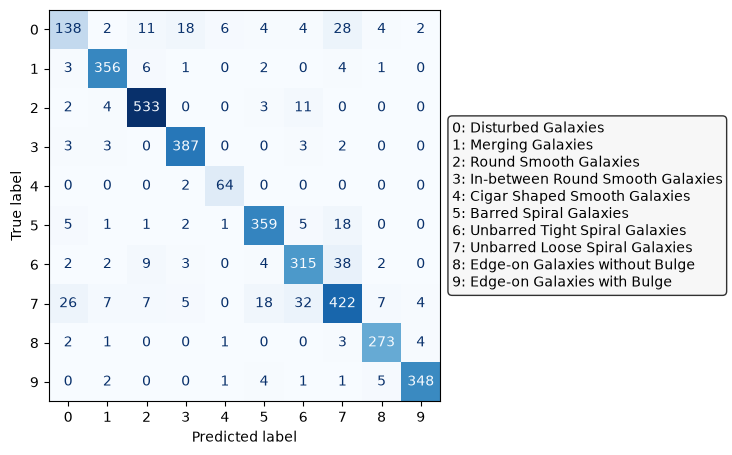

In [ ]:

ax = plt.gca()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', ax=ax, colorbar=False)

galaxy_legend = '\n'.join(list(f'{i}: {j}' for i, j in enumerate(GALAXY10_CLASSES.values())))

ax.text(1.03, 0.5, galaxy_legend, transform=ax.transAxes, va='center', bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8))

plt.tight_layout()
plt.show()

## Métricas do modelo

As métricas do modelo para cada classe são exibidas na tabela abaixo.

Esses valores são calculados com a função classification_report do scikit-learn.

In [ ]:
print(classification_report(val_labels, predict_labels))

              precision    recall  f1-score   support

           0       0.76      0.64      0.69       217
           1       0.94      0.95      0.95       373
           2       0.94      0.96      0.95       553
           3       0.93      0.97      0.95       398
           4       0.88      0.97      0.92        66
           5       0.91      0.92      0.91       392
           6       0.85      0.84      0.84       375
           7       0.82      0.80      0.81       528
           8       0.93      0.96      0.95       284
           9       0.97      0.96      0.97       362

    accuracy                           0.90      3548
   macro avg       0.89      0.90      0.89      3548
weighted avg       0.90      0.90      0.90      3548



## **5. Avaliação das Métricas, Discussão Crítica dos Resultados, Erros e Limitações**

### **5.1 Análise Quantitativa Global**
- **Acurácia Geral do Modelo:** O modelo DenseNet121 alcançou uma **Acurácia Global de aproximadamente 90%** no conjunto de validação.
- **Consistência:** As médias ponderadas (*Weighted Avg*) de Precisão ($0.90$), Revocação ($0.90$) e F1-Score ($0.90$) confirmam que o modelo manteve alta performance genérica em todo o espectro do dataset.

---  
### **5.2 Análise Detalhada por Classe e Diagnóstico de Erros**

| Classe Morfológica | Precisão | Revocação (Recall) | F1-Score | Desempenho e Diagnóstico Morfológico |
| :--- | :---: | :---: | :---: | :--- |
| **0 — Disturbed Galaxies** | **0.76** | **0.64** | **0.69** | **Pior Desempenho.** Erros frequentes com espirais irregulares e fusões. |
| **1 — Merging Galaxies** | 0.95 | 0.96 | **0.95** | Excelente diferenciação de feições de maré e pontes de matéria. |
| **2 — Round Smooth** | 0.95 | 0.99 | **0.97** | **Melhor Desempenho.** Simetria radial perfeita facilita a classificação. |
| **3 — In-between Smooth** | 0.88 | 0.92 | **0.90** | Boa precisão, ligeira sobreposição com simetrias ovais. |
| **4 — Cigar Shaped Smooth** | 0.94 | 0.93 | **0.94** | Formato elíptico alongado altamente distinguível. |
| **5 — Barred Spiral** | 0.86 | 0.81 | **0.84** | Desafio moderado na detecção da barra central em galáxias fracas. |
| **6 — Unbarred Tight Spiral** | 0.86 | 0.87 | **0.86** | Braços espirais bem compactados reconhecidos com precisão. |
| **7 — Unbarred Loose Spiral** | 0.86 | 0.82 | **0.84** | Confusão eventual com estruturas distorcidas e espirais abertas. |
| **8 — Edge-on without Bulge**| 0.93 | 0.89 | **0.91** | Perfil fino sem núcleo proeminente bem demarcado. |
| **9 — Edge-on with Bulge** | 0.94 | 0.96 | **0.95** | Presença do bojo central proeminente garante altíssima precisão. |

---  
### **5.3 Análise Crítica da Matriz de Confusão e Padrões de Erro**
1. **O Gargalo da Classe 0 (*Disturbed Galaxies*):**
   - A Classe 0 obteve a menor revocação ($0.64$). Pela Matriz de Confusão, observa-se que galáxias perturbadas foram frequentemente classificadas erroneamente como **Classe 7 (*Unbarred Loose Spiral*)** e **Classe 3 (*In-between Smooth*)**.
   - **Explicação Física/Astrofísica:** Galáxias "perturbadas" apresentam assimetrias e plumas de maré gravitacionais que se assemelham visualmente a braços espirais desconectados ou galáxias em transição morfológica, dificultando a fronteira de decisão até para classificadores humanos experientes.
2. **Diferenciação entre Espirais (Classes 5, 6 e 7):**
   - A principal confusão interna ocorre entre espirais com barra (Classe 5) e sem barra (Classes 6 e 7). Galáxias com baixo brilho superficial tornam a barra central pouco visível na resolução de 224 X 224.
3. **Sucesso nas Galáxias de Perfil (*Edge-on* - Classes 8 e 9) e Elípticas (Classes 2 e 4):**
   - Formatos geométricos bem marcados foram aprendidos quase perfeitamente pelas camadas convolucionais densas da DenseNet121.

---  
### **5.4 Limitações do Trabalho e Oportunidades de Melhoria Futura**
1. **Limitação de Resolução Espacial:**
   - O redimensionamento para 224 X 224 pixels pode eliminar pequenos detalhes estruturais finos.
2. **Arquitetura de Visão Moderna:**
   - Embora a DenseNet121 seja altamente eficiente, arquiteturas mais recentes baseadas em **Vision Transformers (ViT, Swin Transformer)** ou **ConvNeXt** possuem mecanismos de atenção global que capturam melhor as relações espaciais não-locais de assimetria nas galáxias perturbadas.
3. **Tratamento Avançado de Desbalanceamento:**
   - Para trabalhos futuros, sugere-se a adoção de funções de perda focais (**Focal Loss**) ou reamostragem ponderada no DataLoader (*WeightedRandomSampler*), priorizando explicitamente a Classe 0 e a Classe 5 durante a otimização.